In [ ]:
import main2DIR as dd_ir
import numpy as np

# # testing template function for w_mn terms for the whole 2d spectrum tensor
w_all = {'0': 1., '1': 5., '00': 2., '01': 6., '11': 10.}
Gamma = 10 ** (-0.3)
w1, w2 = np.arange(1, 13, 2), np.arange(1, 13, 2)
w1grid, w2grid = np.meshgrid(w1, w2)
fundamentals = {'0': 1., '1': 5.}

test2d = dd_ir.SpectrumEVV(w1, w2, fundamentals, Gamma, False)

electrical_terms = [('a+b,a', 'zero,a'), ('b,a', 'zero,a')]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))],
                 [('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                    [('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                    [('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                    [('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')]]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc']]

test2d.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)
test2d.combofuns

test2d.gamma_mn(0, 0)

coords_ab = dd_ir.get_abc(2, len(test2d.fundamentals))
test2d.plot2D(coords_ab=coords_ab, coords_abc=[], w1mw2=False)

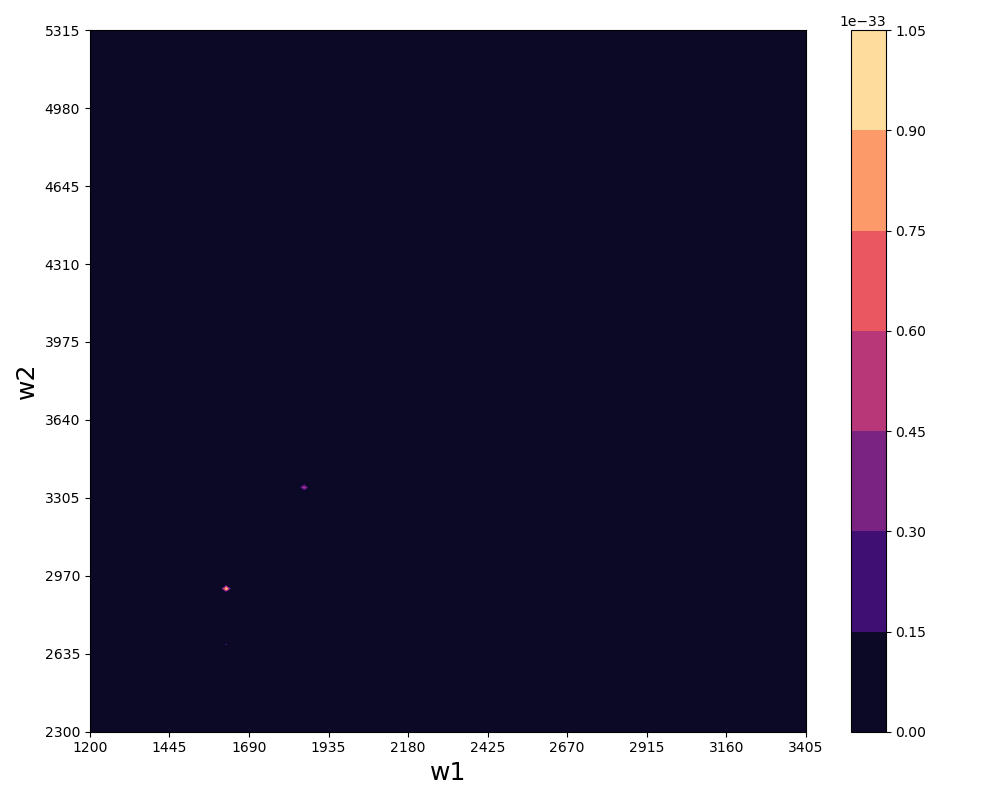

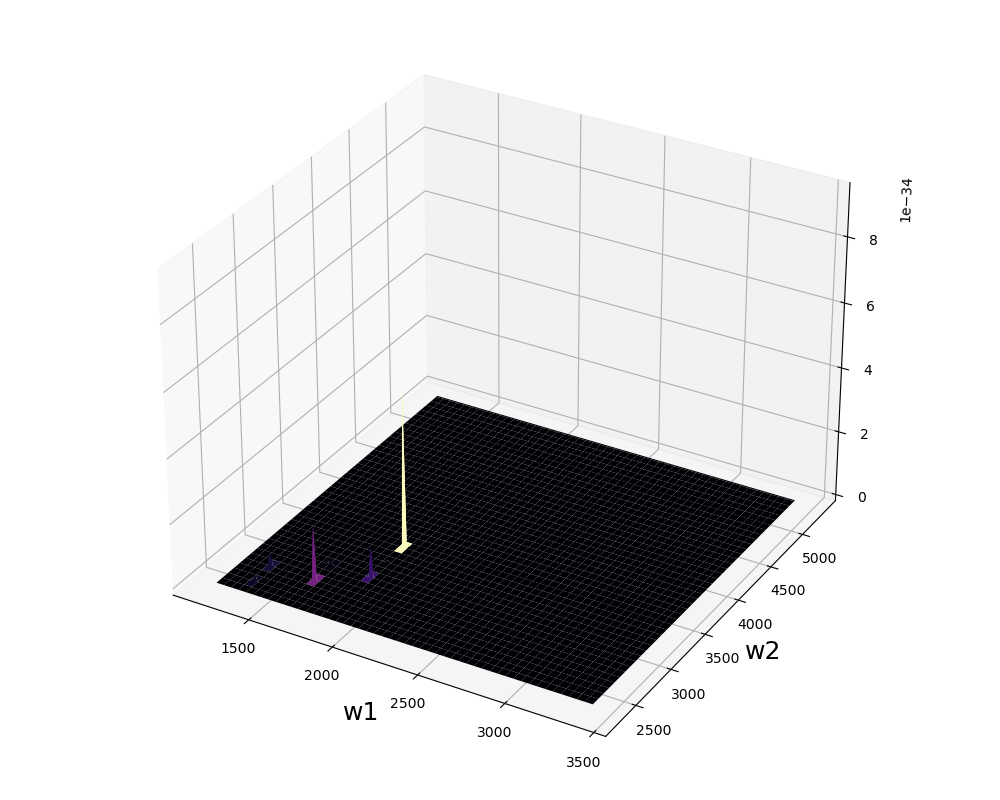

[[1.01060899e-38 7.67845207e-38 6.83041427e-39 ... 2.07726037e-45 1.52791420e-45 1.10513512e-45]
 [1.94770823e-39 1.22648582e-38 9.60716049e-38 ... 2.11402086e-45 1.55543487e-45 1.12549159e-45]
 [7.66101567e-40 2.35371702e-39 1.52111211e-38 ... 2.15173546e-45 1.58367815e-45 1.14639048e-45]
 ...
 [7.04805884e-43 8.53342588e-43 1.05463338e-42 ... 1.33557909e-47 1.94280997e-46 9.32668318e-46]
 [6.97770163e-43 8.44796917e-43 1.04403988e-42 ... 4.02853913e-47 1.15472184e-46 7.23566392e-46]
 [6.90837195e-43 8.36376264e-43 1.03360156e-42 ... 7.93356389e-47 6.05191434e-47 5.52770653e-46]]


In [1]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

# w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)

funds = {'0':20, '1':30
                , '2':50
               }
# funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))
funds = dict(zip(['0', '1', '2', '3', '4', '5'], [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))

h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a')
                   # ('b,a', 'zero,a')
                   ]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
                  #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
                ]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# electrical_terms, electric_avrg = [], []
# mechanical_terms, mechanical_avrg = [], []

h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
coords_abc = dd_ir.get_abc(3, len(h.fundamentals))

# print(coords_abc)

# h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)

print(r)
# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


In [4]:
print(coords_abc[0])

[0 0 0]


In [ ]:
import main2DIR as dd_ir
import numpy as np

Gamma = 10 ** (-0.3)

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     [('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', '00,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

oo = [dd_ir.w_mn_prod(*i) for i in mechanical_terms]

for i in mechanical_terms:
    print(*i)

print(oo)

# w1 = np.arange(0., 8, 1.)
# w2 = np.arange(0., 8, 1.)
w1, w2 = np.array([0, 1, 2, 3, 4]), np.array([0, 1, 2, 3, 4])

X, Y = np.meshgrid(w1, w2)

funds = {'0':2, '1':4
                , '2':6
               }

h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=1, avrg_ones=True)
# print(h.Delta)

import copy
w_all = copy.deepcopy(funds)
w_all.update(h.Delta)

# print(w_all, funds)
print(X)
print(Y)

abctuple = (0, 0, 0)
for i in oo:
    print(i(w_all, X, Y, Gamma, abctuple))